# Analisando investimentos

In [34]:
# Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf
import math

In [35]:
# Lendo o arquivo
caminho = 'Arquivo_Greenblatt.xlsx'
file = pd.ExcelFile(caminho)
abas = file.sheet_names
abas

['Bolsa Greenblatt', 'valor_investido_vs_investimento', 'Compras']

In [36]:
contador = 0 
while contador < 3:
    for guia in abas:
        if contador == 0:
            df_precos = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
        elif contador ==1:
            df_valor_investido_investimento = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
        else:
            df_valor_compras = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
    

In [37]:
df_precos

,Date,SAPR4.SA,TAEE4.SA,CEDO4.SA,EMAE4.SA,PTNT4.SA,AHEB3.SA,GEPA4.SA,POSI3.SA,DOHL4.SA,PETR4.SA
0,2000-01-31,0.000000,0.000000,0.000000,2.400970,0.000000,2.219244,2.615627,0.00,0.868057,1.117574
1,2000-02-29,0.000000,0.000000,0.000000,3.001212,0.000000,2.226641,2.395365,0.00,0.868057,1.265241
2,2000-03-31,0.000000,0.000000,0.000000,2.995210,0.000000,2.234039,1.927304,0.00,0.868057,1.292627
3,2000-04-30,0.000000,0.000000,0.000000,2.460994,0.000000,2.234039,2.285232,0.00,1.041469,1.177824
4,2000-05-31,0.000000,0.000000,0.000000,2.551031,0.000000,2.234039,1.764861,0.00,1.041469,1.147590
...,...,...,...,...,...,...,...,...,...,...,...
295,2024-08-31,5.680338,11.655107,24.500000,40.533104,6.965643,35.000000,24.869888,6.53,4.370000,36.488823
296,2024-09-30,5.787148,11.262679,23.000000,38.880001,6.332402,37.500000,26.328560,5.68,4.190000,33.374714
297,2024-10-31,5.379329,11.429461,24.459999,39.779999,6.280000,38.000000,29.190403,6.41,4.070000,33.282032
298,2024-11-30,5.884248,11.390000,22.000000,39.990002,6.180000,38.000000,29.634438,5.22,4.120000,36.053219


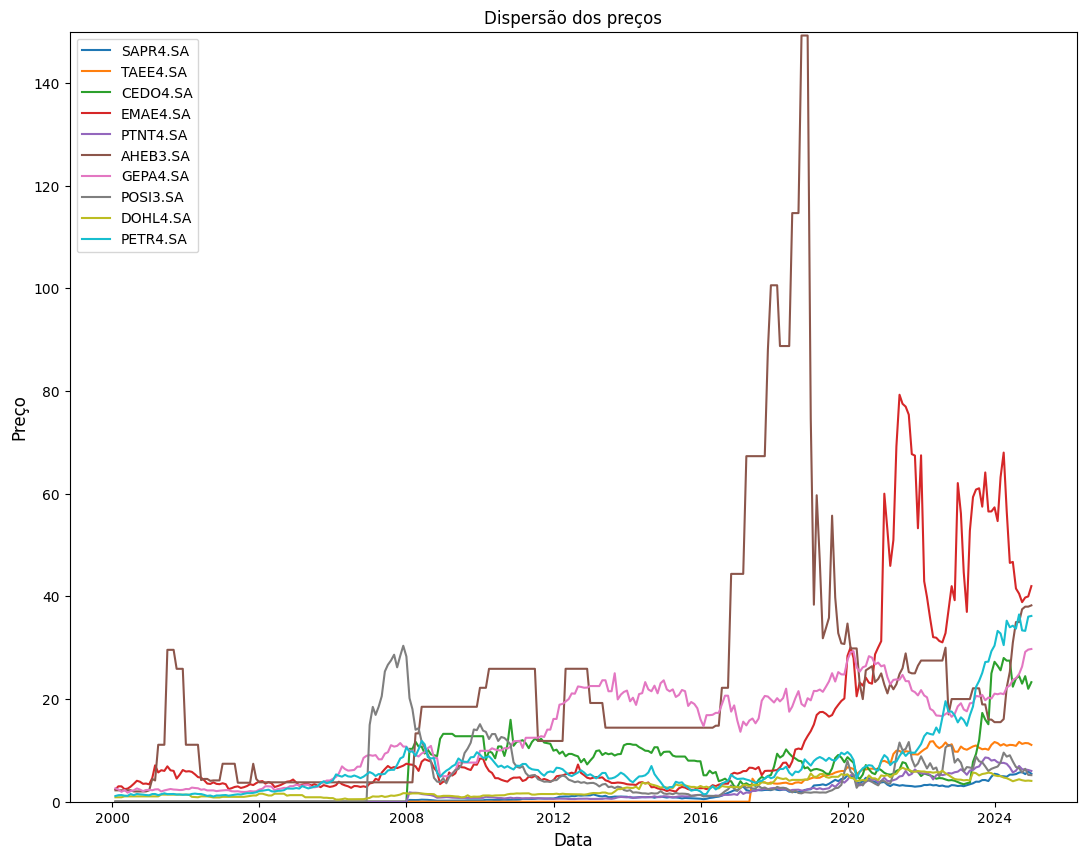

In [38]:
df_precos['Date'] = pd.to_datetime(df_precos['Date'])

plt.figure(figsize=(13,10))
# Para plotar n precisa criar dicionario ou algo do gerando o proprio plt vai implementando
for coluna in df_precos.columns[1:]:
    plt.plot(df_precos['Date'], df_precos[coluna], label=coluna)
plt.title('Dispersão dos preços', fontsize=12)
plt.ylim(0, 150)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço', fontsize=12)
plt.legend(loc='upper left', fontsize=10) 
plt.show()

# oq eu preciso fazer
 - Preciso dos desvios padrões dos ativos
 - retono dos ativos
 - Preciso da correlação entre os ativos, descorbrir um jeito de calcular
 - preciso pegar o valor da ultima linha do preco de cada ativo para calcular o valor da carteira
- Com o valor carteira determinar o percentual de cada ativo na carteira e calcular o retorno esperado
- Depois calcular o risco do portifolio defir uma função que faça isso
- retorno esperado
Calcular o indice sharp , utilizando inflação e selic media
- Calcular a renda anual que a carteira teria
Calcular o ganho de capital
retorno levar em consideração o retorno logaritimo pegar no livro do assaf neto depois (TCC escrito)


In [39]:
array = np.array([df_precos[acao].values for acao in df_precos.columns[1:]])
df_precos.set_index('Date', inplace=True)

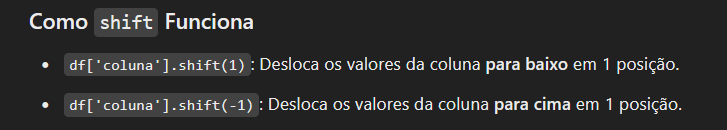

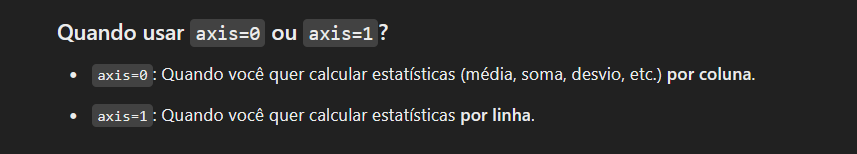

In [40]:
desvio_padro = np.std(array, axis=1)
desvio_padro

array([ 1.61839532,  3.96420619,  6.13082701, 18.4388196 ,  2.18736504,
       24.12147227,  8.40263426,  5.73883251,  1.6945159 ,  7.25419336])

In [41]:
# Ver quantos meses cada acao ficou em negociação para, para definir o retorno anual
dict_ano_negociado = {}
for acao in df_valor_compras['Acao']:
    dict_ano_negociado[acao]= (df_precos[df_precos[acao]!=0][acao].count())/12
dict_ano_negociado

{'SAPR4.SA': np.float64(17.0),
 'TAEE4.SA': np.float64(7.666666666666667),
 'CEDO4.SA': np.float64(17.0),
 'EMAE4.SA': np.float64(25.0),
 'PTNT4.SA': np.float64(17.0),
 'AHEB3.SA': np.float64(25.0),
 'GEPA4.SA': np.float64(25.0),
 'POSI3.SA': np.float64(18.083333333333332),
 'DOHL4.SA': np.float64(25.0),
 'PETR4.SA': np.float64(25.0)}

In [42]:
dict_retornos = {}
for acao in df_valor_compras['Acao']:
    retorno_logaritimo_soma = np.log(df_precos[acao].replace(0,np.nan)/df_precos[acao].replace(0,np.nan).shift(1)).sum()
    vezes_multi_capital = np.exp(retorno_logaritimo_soma)-1
    retorno_anual = (1+vezes_multi_capital)**(1/dict_ano_negociado[acao])-1
    dict_retornos[acao]= retorno_anual*100
dict_retornos

{'SAPR4.SA': np.float64(17.601069546233038),
 'TAEE4.SA': np.float64(12.483123536366204),
 'CEDO4.SA': np.float64(4.915578864511305),
 'EMAE4.SA': np.float64(12.128110137590564),
 'PTNT4.SA': np.float64(7.256669895706547),
 'AHEB3.SA': np.float64(12.061661000210133),
 'GEPA4.SA': np.float64(10.21391875971689),
 'POSI3.SA': np.float64(-5.697192212649949),
 'DOHL4.SA': np.float64(6.365090387984362),
 'PETR4.SA': np.float64(14.924463731230597)}

In [43]:
# Calcular correlações
df_corre = df_precos[[colunas for colunas in df_precos.columns if colunas != 'Date']].replace(0,np.nan)
df_corre

,SAPR4.SA,TAEE4.SA,CEDO4.SA,EMAE4.SA,PTNT4.SA,AHEB3.SA,GEPA4.SA,POSI3.SA,DOHL4.SA,PETR4.SA
Date,,,,,,,,,,
2000-01-31,NaN,NaN,NaN,2.400970,NaN,2.219244,2.615627,NaN,0.868057,1.117574
2000-02-29,NaN,NaN,NaN,3.001212,NaN,2.226641,2.395365,NaN,0.868057,1.265241
2000-03-31,NaN,NaN,NaN,2.995210,NaN,2.234039,1.927304,NaN,0.868057,1.292627
2000-04-30,NaN,NaN,NaN,2.460994,NaN,2.234039,2.285232,NaN,1.041469,1.177824
2000-05-31,NaN,NaN,NaN,2.551031,NaN,2.234039,1.764861,NaN,1.041469,1.147590
...,...,...,...,...,...,...,...,...,...,...
2024-08-31,5.680338,11.655107,24.500000,40.533104,6.965643,35.000000,24.869888,6.53,4.370000,36.488823
2024-09-30,5.787148,11.262679,23.000000,38.880001,6.332402,37.500000,26.328560,5.68,4.190000,33.374714
2024-10-31,5.379329,11.429461,24.459999,39.779999,6.280000,38.000000,29.190403,6.41,4.070000,33.282032


In [44]:
correlacao = df_corre.corr()
correlacao

,SAPR4.SA,TAEE4.SA,CEDO4.SA,EMAE4.SA,PTNT4.SA,AHEB3.SA,GEPA4.SA,POSI3.SA,DOHL4.SA,PETR4.SA
SAPR4.SA,1.000000,0.573778,0.216800,0.746429,0.881078,0.193729,0.679669,-0.016983,0.814060,0.692404
TAEE4.SA,0.573778,1.000000,0.437503,0.814699,0.897130,-0.715785,0.004681,0.831840,0.455847,0.763286
CEDO4.SA,0.216800,0.437503,1.000000,0.197204,0.268671,-0.181683,-0.028373,0.256950,-0.111784,0.696666
EMAE4.SA,0.746429,0.814699,0.197204,1.000000,0.908186,0.108742,0.501889,0.095032,0.768204,0.717565
PTNT4.SA,0.881078,0.897130,0.268671,0.908186,1.000000,0.051407,0.450976,0.225720,0.811247,0.796086
AHEB3.SA,0.193729,-0.715785,-0.181683,0.108742,0.051407,1.000000,0.431457,-0.339778,0.475973,0.134615
GEPA4.SA,0.679669,0.004681,-0.028373,0.501889,0.450976,0.431457,1.000000,-0.502804,0.775398,0.471152
POSI3.SA,-0.016983,0.831840,0.256950,0.095032,0.225720,-0.339778,-0.502804,1.000000,-0.291919,0.170269
DOHL4.SA,0.814060,0.455847,-0.111784,0.768204,0.811247,0.475973,0.775398,-0.291919,1.000000,0.543344
PETR4.SA,0.692404,0.763286,0.696666,0.717565,0.796086,0.134615,0.471152,0.170269,0.543344,1.000000


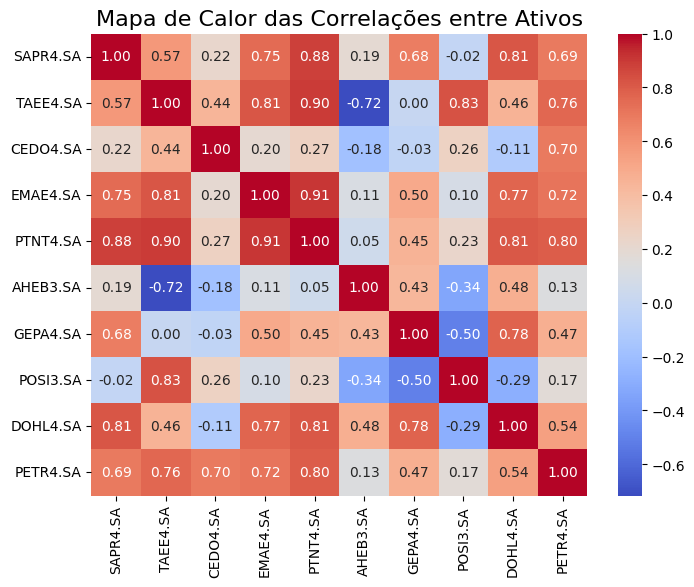

In [45]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)

# Personalizando o gráfico
plt.title('Mapa de Calor das Correlações entre Ativos', fontsize=16)
plt.show()

In [46]:
desvio_padro

array([ 1.61839532,  3.96420619,  6.13082701, 18.4388196 ,  2.18736504,
       24.12147227,  8.40263426,  5.73883251,  1.6945159 ,  7.25419336])

In [47]:
dict_desvio = {acao:0 for acao in df_valor_compras['Acao']}
contador = 0
for acao in df_valor_compras['Acao']:
    dict_desvio[acao]= desvio_padro[contador]
    contador +=1
dict_desvio

{'SAPR4.SA': np.float64(1.6183953170772234),
 'TAEE4.SA': np.float64(3.964206193219218),
 'CEDO4.SA': np.float64(6.130827013872151),
 'EMAE4.SA': np.float64(18.43881960419703),
 'PTNT4.SA': np.float64(2.187365038048453),
 'AHEB3.SA': np.float64(24.121472268518872),
 'GEPA4.SA': np.float64(8.402634263548283),
 'POSI3.SA': np.float64(5.738832510038153),
 'DOHL4.SA': np.float64(1.6945158965696276),
 'PETR4.SA': np.float64(7.254193357761582)}

In [48]:
df_precos_final = df_precos[[colunas for colunas in df_precos.columns if colunas != 'Date']].tail(1)
df_precos_final

,SAPR4.SA,TAEE4.SA,CEDO4.SA,EMAE4.SA,PTNT4.SA,AHEB3.SA,GEPA4.SA,POSI3.SA,DOHL4.SA,PETR4.SA
Date,,,,,,,,,,
2024-12-31,5.457009,11.07,23.290001,42.0,6.0,38.25,29.75,5.18,4.06,36.189999


In [49]:
dict_valor_ativo = {}
contador = 0
while contador < len(df_valor_compras):
    acao = qtd=df_valor_compras.loc[contador,'Acao']
    qtd=df_valor_compras.loc[contador,'Qtd_comprada']
    dict_valor_ativo[acao]=qtd
    contador += 1
dict_valor_ativo
        

{'SAPR4.SA': np.int64(434),
 'TAEE4.SA': np.int64(112),
 'CEDO4.SA': np.int64(228),
 'EMAE4.SA': np.int64(375),
 'PTNT4.SA': np.int64(330),
 'AHEB3.SA': np.int64(226),
 'GEPA4.SA': np.int64(236),
 'POSI3.SA': np.int64(183),
 'DOHL4.SA': np.int64(360),
 'PETR4.SA': np.int64(169)}

In [50]:
valor_total = 0
porcentagem_ativo = {}
for acao in dict_valor_ativo.keys():
    preco = df_precos_final[acao].values
    qtd = dict_valor_ativo[acao]
    valor_total += preco*qtd
print(valor_total)


[50839.45172644]


In [ ]:
porcentagem_ativo = {}
for acao in dict_valor_ativo.keys():
    preco = df_precos_final[acao].values
    qtd = dict_valor_ativo[acao]
    porcentagem_ativo[acao]= (preco*qtd)/valor_total
porcentagem_ativo

{'SAPR4.SA': array([0.04658472]), 'TAEE4.SA': array([0.02438736]), 'CEDO4.SA': array([0.10444881]), 'EMAE4.SA': array([0.30979878]), 'PTNT4.SA': array([0.03894613]), 'AHEB3.SA': array([0.17003527]), 'GEPA4.SA': array([0.13810141]), 'POSI3.SA': array([0.01864576]), 'DOHL4.SA': array([0.02874933]), 'PETR4.SA': array([0.12030243])}


In [52]:
def variancia_risco_port(participacao_1,participacao_2,delta_1,delta_2,corr_1_2):
    variancia = participacao_1*participacao_2*delta_1*delta_2*corr_1_2
    return variancia

In [53]:
correlacao

,SAPR4.SA,TAEE4.SA,CEDO4.SA,EMAE4.SA,PTNT4.SA,AHEB3.SA,GEPA4.SA,POSI3.SA,DOHL4.SA,PETR4.SA
SAPR4.SA,1.000000,0.573778,0.216800,0.746429,0.881078,0.193729,0.679669,-0.016983,0.814060,0.692404
TAEE4.SA,0.573778,1.000000,0.437503,0.814699,0.897130,-0.715785,0.004681,0.831840,0.455847,0.763286
CEDO4.SA,0.216800,0.437503,1.000000,0.197204,0.268671,-0.181683,-0.028373,0.256950,-0.111784,0.696666
EMAE4.SA,0.746429,0.814699,0.197204,1.000000,0.908186,0.108742,0.501889,0.095032,0.768204,0.717565
PTNT4.SA,0.881078,0.897130,0.268671,0.908186,1.000000,0.051407,0.450976,0.225720,0.811247,0.796086
AHEB3.SA,0.193729,-0.715785,-0.181683,0.108742,0.051407,1.000000,0.431457,-0.339778,0.475973,0.134615
GEPA4.SA,0.679669,0.004681,-0.028373,0.501889,0.450976,0.431457,1.000000,-0.502804,0.775398,0.471152
POSI3.SA,-0.016983,0.831840,0.256950,0.095032,0.225720,-0.339778,-0.502804,1.000000,-0.291919,0.170269
DOHL4.SA,0.814060,0.455847,-0.111784,0.768204,0.811247,0.475973,0.775398,-0.291919,1.000000,0.543344
PETR4.SA,0.692404,0.763286,0.696666,0.717565,0.796086,0.134615,0.471152,0.170269,0.543344,1.000000


In [54]:
variacia_port = 0
for acao_1 in df_valor_compras['Acao']:
    for acao_2 in df_valor_compras['Acao']:
        participacao_1 = porcentagem_ativo[acao_1]
        participacao_2 = porcentagem_ativo[acao_2]
        desv_padro_1 = dict_desvio[acao_1]
        desv_padro_2 = dict_desvio[acao_2]
        corre = correlacao.loc[acao_1,acao_2]
        variacia_port +=variancia_risco_port(participacao_1,participacao_2,desv_padro_1,desv_padro_2,corre)
desv_pad_port=variacia_port**(1/2)
desv_pad_port

array([9.02226846])

# Quando se junta 2 arrays em um terceiro eles apenas pegam cada array e transforma numa dimensaõ de um terceiro, para juntar 2 arrays em 1 só é necessario concatenar
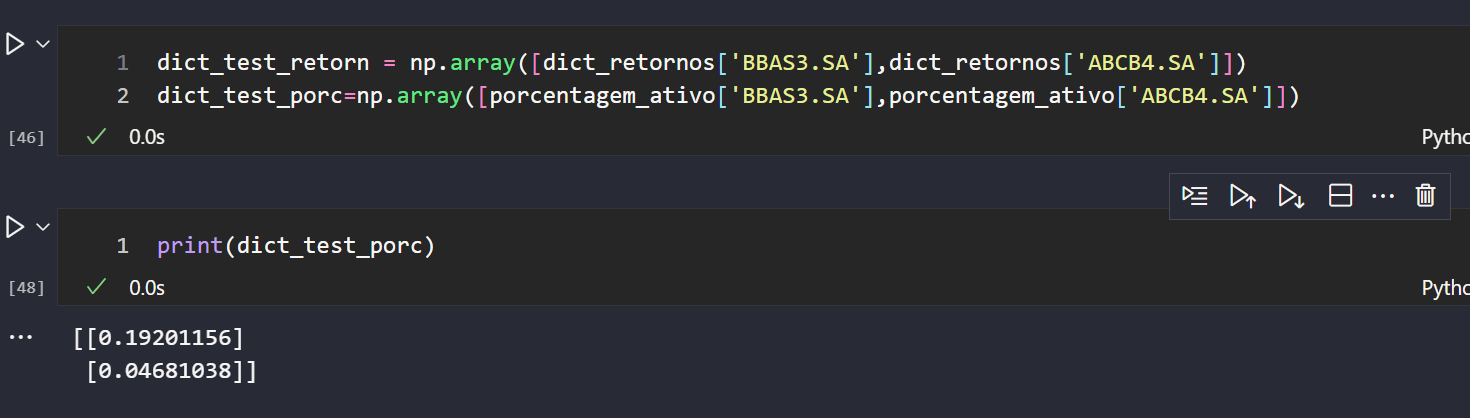

In [55]:
retornos = np.array([dict_retornos[acao] for acao in dict_retornos.keys()])
porcentagens=np.concatenate([porcentagem_ativo[acao] for acao in porcentagem_ativo.keys()])

In [56]:
print(retornos,porcentagens)

[17.60106955 12.48312354  4.91557886 12.12811014  7.2566699  12.061661
 10.21391876 -5.69719221  6.36509039 14.92446373] [0.04658472 0.02438736 0.10444881 0.30979878 0.03894613 0.17003527
 0.13810141 0.01864576 0.02874933 0.12030243]


In [57]:
retorno_esperado = sum(retornos*porcentagens)
retorno_esperado

np.float64(11.011367979939912)

In [58]:
df_valor_investido_investimento

,Nome,Valor
0,carteira_contabil_greenblatt,14973.113654
1,valor_investido_greenblatt,14973.120000


In [59]:
Total_capital_faltou_investir = df_valor_investido_investimento.loc[1,'Valor',] - df_valor_investido_investimento.loc[0,'Valor',] 
Total_capital_faltou_investir

np.float64(0.006345848449200275)

In [60]:
ganho_capital = valor_total - df_valor_investido_investimento.loc[1,'Valor',]
ganho_capital

array([35866.33172644])

In [61]:
contador = 0
valor_recebido_total = 0
while contador < len(df_valor_compras):
    for acao in df_valor_compras['Acao']:
        empresa = yf.Ticker(acao)
        dividendos = empresa.dividends
        if not dividendos.empty:
            dividendos_anuais_geral = dividendos.groupby(dividendos.index.year).sum()
            dividendo_ultimo_ano = dividendos_anuais_geral.tail(1)
            valor_pago = df_valor_compras.loc[contador, 'Qtd_comprada'] * dividendo_ultimo_ano.values
            valor_recebido_total+= valor_pago
            print(dividendo_ultimo_ano,valor_pago)
        else:
            valor_pago = 0  
        contador +=1
valor_recebido_total
        

Date
2025    0.162991
Name: Dividends, dtype: float64 [70.738094]
Date
2024    1.177485
Name: Dividends, dtype: float64 [131.87832]
Date
2013    0.3
Name: Dividends, dtype: float64 [68.4]
Date
2024    1.632526
Name: Dividends, dtype: float64 [612.19725]
Date
2024    0.249758
Name: Dividends, dtype: float64 [82.42014]
Date
2024    5.99365
Name: Dividends, dtype: float64 [1414.5014]
Date
2024    0.418228
Name: Dividends, dtype: float64 [76.535724]
Date
2022    0.132
Name: Dividends, dtype: float64 [47.52]
Date
2024    7.913786
Name: Dividends, dtype: float64 [1337.429834]


array([3841.620762])

In [62]:
SELIC_MEDIA = 12.15999870500932
DESV_PAD_SELIC = 4.793701588763131
INFLACAO = 6.18

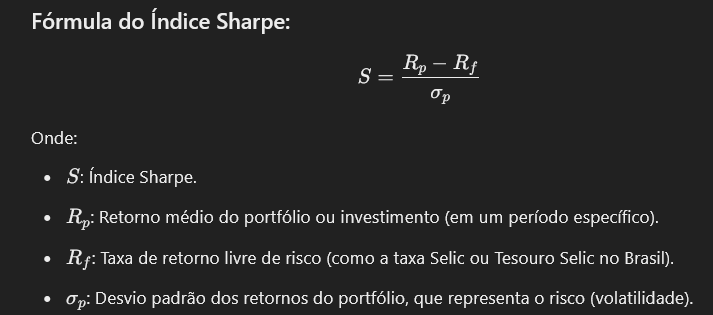

In [63]:
indice_sharpe_inflação = (retorno_esperado - INFLACAO)/desv_pad_port
indice_sharpe_inflação

print(f'Oferece um retorono de {indice_sharpe_inflação} para cada unidade de risco assumido')

Oferece um retorono de [0.53549371] para cada unidade de risco assumido


In [64]:
# Para taxa que sofre grandes variações pode se considerar o desvio padrao desse retorno no indice sharpe
# Devido a cenario de economia emergente e longo prazo gera essa variação

indice_sharpe_selic = (retorno_esperado-SELIC_MEDIA)/desv_pad_port[0]
indice_sharpe_selic
print(f'Oferece um retorono de {indice_sharpe_selic} para cada unidade de risco assumido')

Oferece um retorono de -0.1273106347845237 para cada unidade de risco assumido


In [65]:
dados = {'risco_portifolio':desv_pad_port, 'Retorno_portifolio':retorno_esperado,
         'Indice_sharpe_inflacao':indice_sharpe_inflação,
         'indice_sharpe_selic':indice_sharpe_selic, 'Dividendos':valor_recebido_total
         ,'ganho_capital':ganho_capital}
dados_df=pd.DataFrame(dados)

In [66]:
with pd.ExcelWriter('base_analise_greenblatt.xlsx',engine='openpyxl') as writer:
        dados_df.to_excel(writer,sheet_name='Analise', index=False)
